Analyzing 749 images...
749


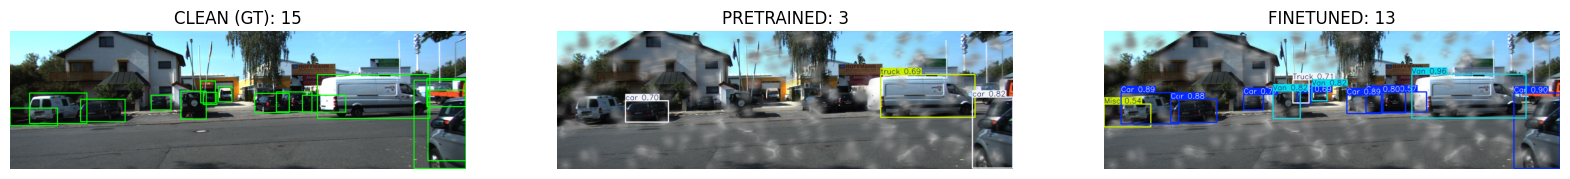

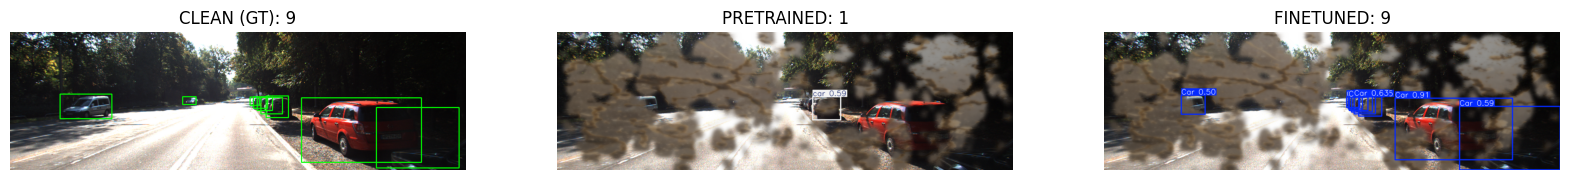

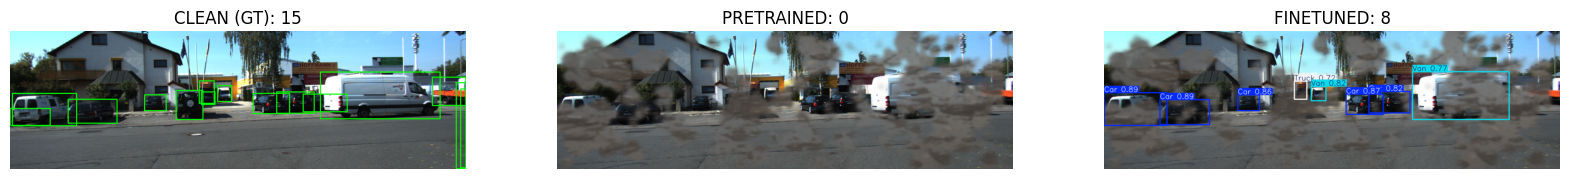

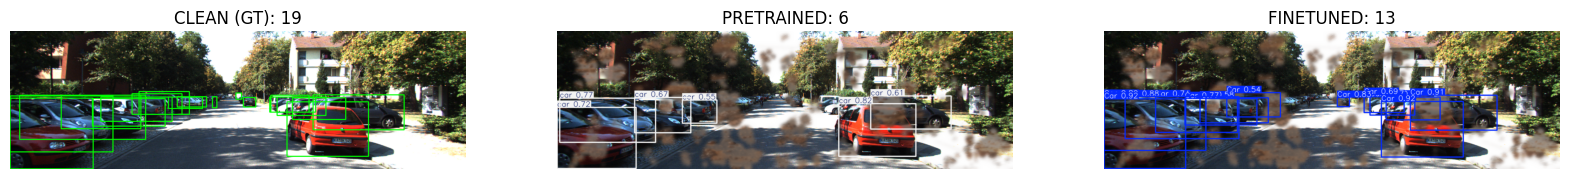

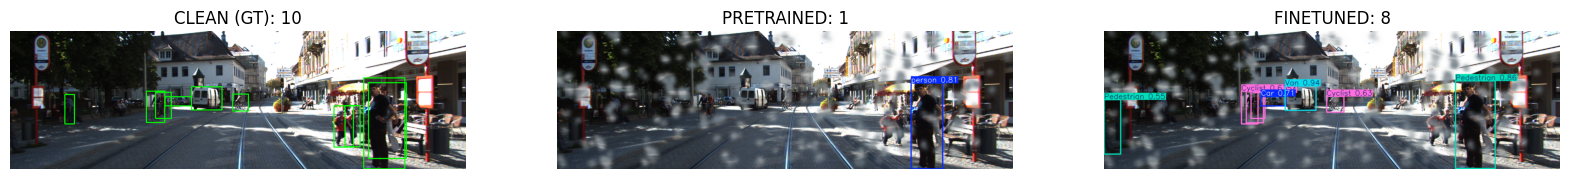


FINAL REPORT: GT vs PRETRAINED vs FINETUNED
Total Objects (GT Clean):       4055
Total Detections (Pretrained):  1745 | Loss: 56.97%
Total Detections (Finetuned):   3085 | Loss: 23.92%
------------------------------
Mean Confidence (GT Clean):      1.0000
Mean Confidence (Pretrained):    0.7005 | Drop: 29.95%
Mean Confidence (Finetuned):     0.7996 | Drop: 20.04%


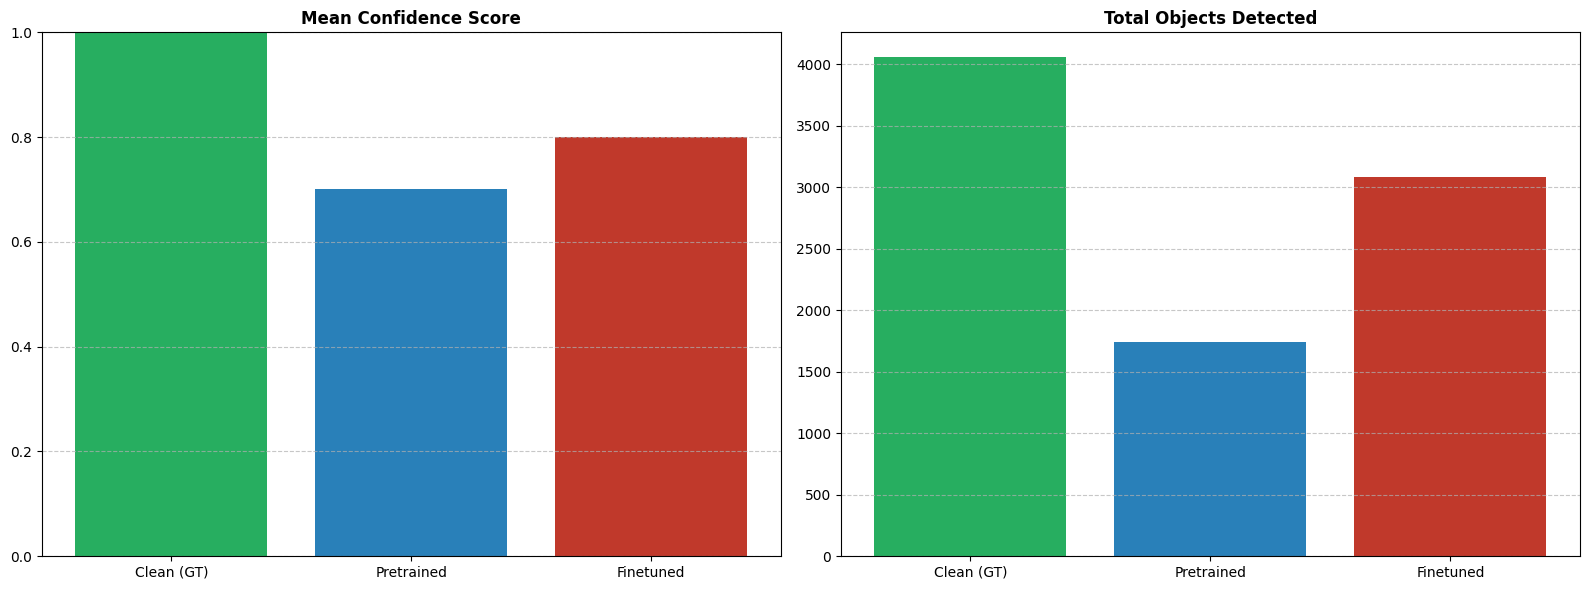

In [9]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# =========================
# Helper: Draw GT boxes
# =========================
def draw_gt_boxes(image_path, label_path, class_filter=None):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    boxes = []

    if not os.path.exists(label_path):
        return img, boxes

    with open(label_path, 'r') as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.strip().split())
            cls = int(cls)

            if class_filter is not None and cls not in class_filter:
                continue

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            boxes.append(cls)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    return img, boxes

# =========================
# Setup: Load models
# =========================
pretrained_model = YOLO('../yolov8n.pt')
finetuned_model = YOLO(r".\best.pt")  # fine-tuned model

kitti_like_classes = [0, 1, 2, 3, 5, 7]

clean_img_dir = r".\dataset\clean\images\test"
clean_lbl_dir = r".\dataset\clean\labels\test"
dirty_dir = r".\dataset\images\test"

dirty_images = glob.glob(os.path.join(dirty_dir, "*.png"))

max_samples = 5

# =========================
# Metrics & Sample Storage
# =========================
all_clean_confs, all_pretrained_confs, all_ft_confs = [], [], []
total_clean_objs, total_pretrained_objs, total_ft_objs = 0, 0, 0
improvement_samples = []

print(f"Analyzing {len(dirty_images)} images...")

# =========================
# Main Loop
# =========================
print(len(dirty_images))
for d_path in dirty_images:
    base_name = os.path.basename(d_path).split('_')[0]
    c_path = os.path.join(clean_img_dir, f"{base_name}.png")
    l_path = os.path.join(clean_lbl_dir, f"{base_name}.txt")

    if not os.path.exists(c_path):
        continue

    # --- CLEAN: GT only ---
    clean_img_gt, clean_boxes = draw_gt_boxes(c_path, l_path, class_filter=kitti_like_classes)
    c_confs = [1.0] * len(clean_boxes)
    total_clean_objs += len(clean_boxes)
    all_clean_confs.extend(c_confs)

    # --- DIRTY: Pretrained YOLO ---
    res_pretrained = pretrained_model.predict(d_path, classes=kitti_like_classes, verbose=False, conf=0.5)[0]
    p_confs = res_pretrained.boxes.conf.cpu().numpy() if len(res_pretrained.boxes) > 0 else []
    total_pretrained_objs += len(res_pretrained.boxes)
    all_pretrained_confs.extend(p_confs)

    # --- DIRTY: Fine-tuned YOLO ---
    res_ft = finetuned_model.predict(d_path, classes=kitti_like_classes, verbose=False, conf=0.5)[0]
    ft_confs = res_ft.boxes.conf.cpu().numpy() if len(res_ft.boxes) > 0 else []
    total_ft_objs += len(res_ft.boxes)
    all_ft_confs.extend(ft_confs)

    # --- Select images where pretrained < GT ---
    if len(res_pretrained.boxes) < len(clean_boxes):
        pretrained_error = abs(len(clean_boxes) - len(res_pretrained.boxes))
        ft_error = abs(len(clean_boxes) - len(res_ft.boxes))
        improvement = pretrained_error - ft_error

        improvement_samples.append({
            "img_name": base_name,
            "clean_img": clean_img_gt,
            "pretrained_img": cv2.cvtColor(res_pretrained.plot(), cv2.COLOR_BGR2RGB),
            "ft_img": cv2.cvtColor(res_ft.plot(), cv2.COLOR_BGR2RGB),
            "clean_count": len(clean_boxes),
            "pretrained_count": len(res_pretrained.boxes),
            "ft_count": len(res_ft.boxes),
            "improvement": improvement
        })

# Sort and pick top 5
top_samples = sorted(improvement_samples, key=lambda x: x["improvement"], reverse=True)[:max_samples]

# =========================
# Display Top Improvement Samples
# =========================
for sample in top_samples:
    fig, ax = plt.subplots(1, 3, figsize=(20, 7))
    ax[0].imshow(sample["clean_img"])
    ax[0].set_title(f"CLEAN (GT): {sample['clean_count']}")
    ax[0].axis('off')

    ax[1].imshow(sample["pretrained_img"])
    ax[1].set_title(f"PRETRAINED: {sample['pretrained_count']}")
    ax[1].axis('off')

    ax[2].imshow(sample["ft_img"])
    ax[2].set_title(f"FINETUNED: {sample['ft_count']}")
    ax[2].axis('off')
    plt.show()

# =========================
# Compute Final Metrics
# =========================
mean_clean_conf = np.mean(all_clean_confs) if all_clean_confs else 0
mean_pretrained_conf = np.mean(all_pretrained_confs) if all_pretrained_confs else 0
mean_ft_conf = np.mean(all_ft_confs) if all_ft_confs else 0

pretrained_obj_loss_pct = ((total_clean_objs - total_pretrained_objs) / total_clean_objs) * 100 if total_clean_objs > 0 else 0
ft_obj_loss_pct = ((total_clean_objs - total_ft_objs) / total_clean_objs) * 100 if total_clean_objs > 0 else 0

pretrained_conf_drop_pct = ((mean_clean_conf - mean_pretrained_conf) / mean_clean_conf) * 100 if mean_clean_conf > 0 else 0
ft_conf_drop_pct = ((mean_clean_conf - mean_ft_conf) / mean_clean_conf) * 100 if mean_clean_conf > 0 else 0

print("\n" + "="*50)
print("FINAL REPORT: GT vs PRETRAINED vs FINETUNED")
print("="*50)
print(f"Total Objects (GT Clean):       {total_clean_objs}")
print(f"Total Detections (Pretrained):  {total_pretrained_objs} | Loss: {pretrained_obj_loss_pct:.2f}%")
print(f"Total Detections (Finetuned):   {total_ft_objs} | Loss: {ft_obj_loss_pct:.2f}%")
print("-"*30)
print(f"Mean Confidence (GT Clean):      {mean_clean_conf:.4f}")
print(f"Mean Confidence (Pretrained):    {mean_pretrained_conf:.4f} | Drop: {pretrained_conf_drop_pct:.2f}%")
print(f"Mean Confidence (Finetuned):     {mean_ft_conf:.4f} | Drop: {ft_conf_drop_pct:.2f}%")
print("="*50)

# =========================
# Final Plot: GT vs Pretrained vs Fine-tuned
# =========================
labels = ['Clean (GT)', 'Pretrained', 'Finetuned']
conf_vals = [mean_clean_conf, mean_pretrained_conf, mean_ft_conf]
obj_vals = [total_clean_objs, total_pretrained_objs, total_ft_objs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(labels, conf_vals, color=['#27ae60', '#2980b9', '#c0392b'])
ax1.set_title('Mean Confidence Score', fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2.bar(labels, obj_vals, color=['#27ae60', '#2980b9', '#c0392b'])
ax2.set_title('Total Objects Detected', fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [12]:
# =========================
# Additional Evaluation Metrics
# =========================
def compute_iou(box1, box2):
    """
    box = [x1, y1, x2, y2]
    Returns IoU between two boxes
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union_area = area1 + area2 - inter_area
    return inter_area / union_area if union_area > 0 else 0

def get_boxes_from_yolo(yolo_result):
    """
    Converts YOLOv8 results to [x1, y1, x2, y2] list
    """
    if len(yolo_result.boxes) == 0:
        return []
    boxes = yolo_result.boxes.xyxy.cpu().numpy()
    return boxes.tolist()

# IoU threshold for considering a detection correct
iou_threshold = 0.5

# Store overall metrics
all_precisions, all_recalls, all_f1s = [], [], []

for d_path in dirty_images:
    base_name = os.path.basename(d_path).split('_')[0]
    c_path = os.path.join(clean_img_dir, f"{base_name}.png")
    l_path = os.path.join(clean_lbl_dir, f"{base_name}.txt")

    if not os.path.exists(c_path):
        continue

    # --- GT boxes ---
    _, clean_boxes_cls = draw_gt_boxes(c_path, l_path, class_filter=kitti_like_classes)

    # Load GT boxes in [x1,y1,x2,y2] format
    clean_boxes_coords = []
    with open(l_path, 'r') as f:
        img = cv2.imread(c_path)
        h, w, _ = img.shape
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.strip().split())
            cls = int(cls)
            if cls not in kitti_like_classes:
                continue
            x1 = int((xc - bw/2)*w)
            y1 = int((yc - bh/2)*h)
            x2 = int((xc + bw/2)*w)
            y2 = int((yc + bh/2)*h)
            clean_boxes_coords.append([x1, y1, x2, y2])

    # --- Predictions ---
    res_ft = finetuned_model.predict(d_path, classes=kitti_like_classes, verbose=False)[0]
    res_pretrained = pretrained_model.predict(d_path, classes=kitti_like_classes, verbose=False)[0]

    ft_boxes = get_boxes_from_yolo(res_ft)
    pt_boxes = get_boxes_from_yolo(res_pretrained)

    # Function to compute precision/recall
    def compute_pr(pred_boxes, gt_boxes, iou_thresh):
        matched_gt = set()
        TP = 0
        for pb in pred_boxes:
            for i, gb in enumerate(gt_boxes):
                if i in matched_gt:
                    continue
                iou = compute_iou(pb, gb)
                if iou >= iou_thresh:
                    TP += 1
                    matched_gt.add(i)
                    break
        FP = len(pred_boxes) - TP
        FN = len(gt_boxes) - TP
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        return precision, recall, f1

    # Compute metrics
    ft_prec, ft_rec, ft_f1 = compute_pr(ft_boxes, clean_boxes_coords, iou_threshold)
    pt_prec, pt_rec, pt_f1 = compute_pr(pt_boxes, clean_boxes_coords, iou_threshold)

    all_precisions.append([pt_prec, ft_prec])
    all_recalls.append([pt_rec, ft_rec])
    all_f1s.append([pt_f1, ft_f1])

# Convert to numpy arrays for easier computation
all_precisions = np.array(all_precisions)
all_recalls = np.array(all_recalls)
all_f1s = np.array(all_f1s)

# Average across all images
avg_prec = np.mean(all_precisions, axis=0)
avg_rec = np.mean(all_recalls, axis=0)
avg_f1 = np.mean(all_f1s, axis=0)

print("\n" + "="*50)
print("ADDITIONAL METRICS: PRETRAINED vs FINETUNED")
print("="*50)
print(f"Precision:   Pretrained: {avg_prec[0]:.4f} | Finetuned: {avg_prec[1]:.4f}")
print(f"Recall:      Pretrained: {avg_rec[0]:.4f} | Finetuned: {avg_rec[1]:.4f}")
print(f"F1 Score:    Pretrained: {avg_f1[0]:.4f} | Finetuned: {avg_f1[1]:.4f}")
print("="*50)



ADDITIONAL METRICS: PRETRAINED vs FINETUNED
Precision:   Pretrained: 0.5850 | Finetuned: 0.8413
Recall:      Pretrained: 0.5334 | Finetuned: 0.8403
F1 Score:    Pretrained: 0.5294 | Finetuned: 0.8256


In [2]:
%pip install pandas

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   ------------- -------------------------- 3.9/11.3 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 32.0 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 21.5 MB/s  0:00:00
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- -------------

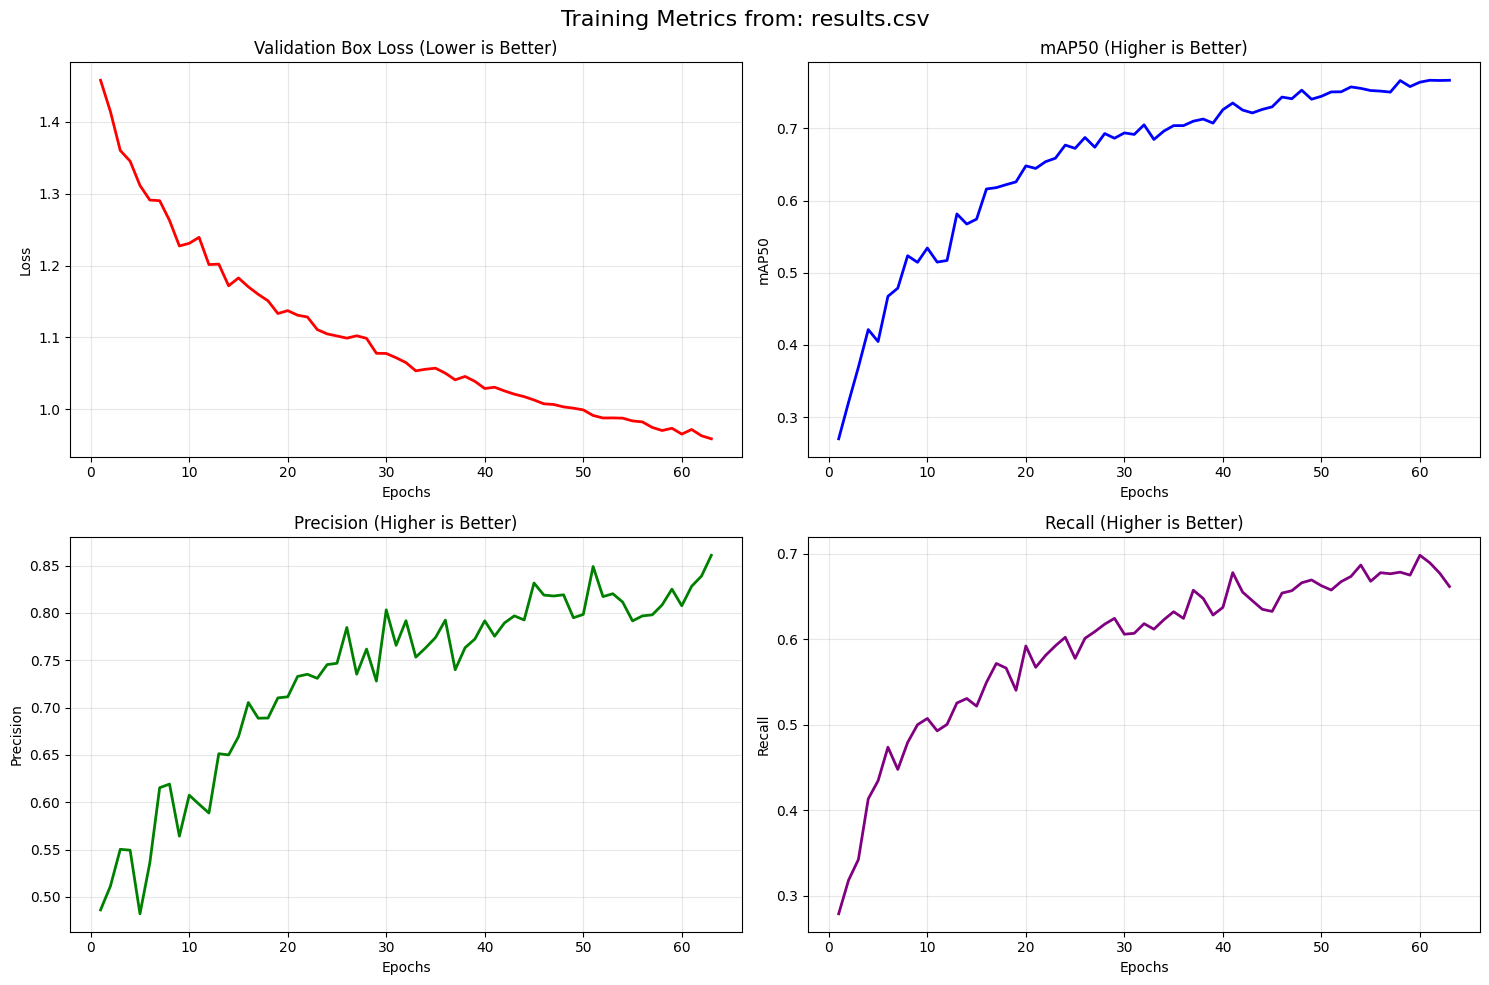

Generating Confusion Matrix on Validation/Test set...
Ultralytics 8.4.5  Python-3.11.1 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti, 8192MiB)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2575.7890.0 MB/s, size: 775.5 KB)
val: Scanning C:\Dev\Gen-AI\dataset\labels\test... 749 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 749/749 632.3it/s 1.2s0.0s
val: New cache created: C:\Dev\Gen-AI\dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 10.6it/s 4.4s0.1s
                   all        749       4123      0.773      0.669      0.746        0.5
                   Car        668       2876      0.897      0.848      0.919      0.702
                   Van        218        300      0.872      0.728      0.845       0.61
                 Truck        106        114      0.872      0.838      0.901      0.688
  

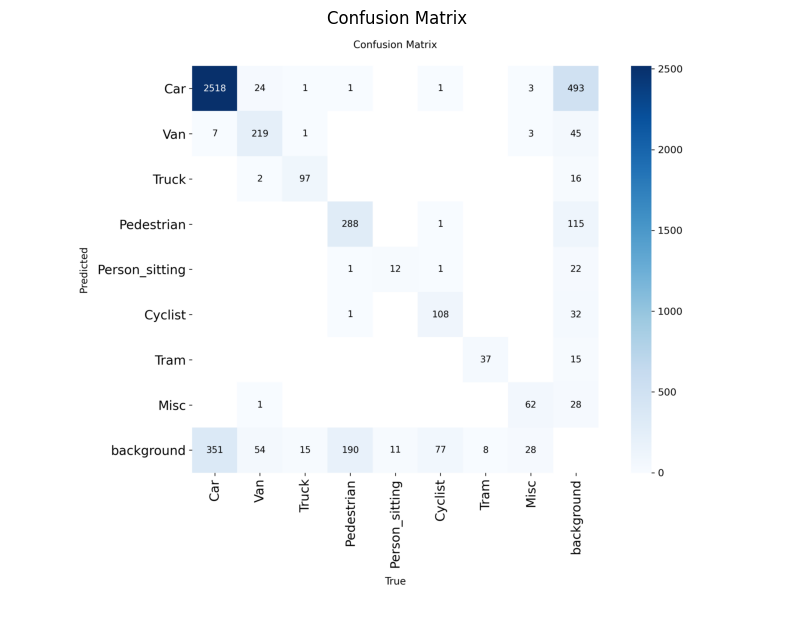

Confusion Matrix saved at: C:\Users\guyy6\runs\detect\val2\confusion_matrix.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from ultralytics import YOLO
import cv2

# ==========================================
# הגדרות - שנה את הנתיבים האלו לשלך
# ==========================================
RESULTS_CSV_PATH = r"results.csv"  # הנתיב לקובץ ה-CSV שנוצר באימון
MODEL_PATH = "best.pt"                               # המודל המאומן
DATA_YAML_PATH = r"dataset/data.yaml"                # קובץ הגדרות הדאטה

# ==========================================
# חלק 1: הצגת גרפים מתוך היסטוריית האימון
# ==========================================
def plot_training_history(csv_path):
    if not os.path.exists(csv_path):
        print(f"❌ Error: Could not find results file at {csv_path}")
        return

    # טעינת הנתונים וניקוי רווחים בשמות העמודות
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    # יצירת לוח גרפים (2x2)
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Training Metrics from: {os.path.basename(csv_path)}', fontsize=16)

    epochs = df['epoch']

    # 1. Box Loss (Validation) - ירידת הלוס
    # בודקים איזה שם עמודה קיים (משתנה בין גרסאות)
    loss_col = 'val/box_loss' if 'val/box_loss' in df.columns else 'val/box_loss(M)'
    if loss_col in df.columns:
        axs[0, 0].plot(epochs, df[loss_col], color='red', linewidth=2)
        axs[0, 0].set_title('Validation Box Loss (Lower is Better)')
        axs[0, 0].set_xlabel('Epochs')
        axs[0, 0].set_ylabel('Loss')
        axs[0, 0].grid(True, alpha=0.3)

    # 2. mAP50 - עליית הדיוק הכללי
    map_col = 'metrics/mAP50(B)'
    if map_col in df.columns:
        axs[0, 1].plot(epochs, df[map_col], color='blue', linewidth=2)
        axs[0, 1].set_title('mAP50 (Higher is Better)')
        axs[0, 1].set_xlabel('Epochs')
        axs[0, 1].set_ylabel('mAP50')
        axs[0, 1].grid(True, alpha=0.3)

    # 3. Precision - דיוק
    prec_col = 'metrics/precision(B)'
    if prec_col in df.columns:
        axs[1, 0].plot(epochs, df[prec_col], color='green', linewidth=2)
        axs[1, 0].set_title('Precision (Higher is Better)')
        axs[1, 0].set_xlabel('Epochs')
        axs[1, 0].set_ylabel('Precision')
        axs[1, 0].grid(True, alpha=0.3)

    # 4. Recall - ריקול
    rec_col = 'metrics/recall(B)'
    if rec_col in df.columns:
        axs[1, 1].plot(epochs, df[rec_col], color='purple', linewidth=2)
        axs[1, 1].set_title('Recall (Higher is Better)')
        axs[1, 1].set_xlabel('Epochs')
        axs[1, 1].set_ylabel('Recall')
        axs[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# חלק 2: יצירת Confusion Matrix
# ==========================================
def generate_and_show_confusion_matrix(model_path, data_yaml):
    print("Generating Confusion Matrix on Validation/Test set...")
    model = YOLO(model_path)
    
    # הרצת ולידציה - זה ייצר את המטריצה וישמור אותה בתיקיית runs
    # plots=True מוודא שהגרפים נוצרים
    metrics = model.val(data=data_yaml, split='test', plots=True) 
    
    # מציאת הנתיב שבו נשמרה המטריצה
    save_dir = metrics.save_dir # הנתיב בו נשמרו התוצאות
    cm_path = os.path.join(save_dir, 'confusion_matrix.png')
    
    # הצגת התמונה אם נוצרה
    if os.path.exists(cm_path):
        img = cv2.imread(cm_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(img_rgb)
        plt.title('Confusion Matrix')
        plt.axis('off')
        plt.show()
        print(f"Confusion Matrix saved at: {cm_path}")
    else:
        print(f"Could not find confusion matrix image at {cm_path}")
        print("Check usually: runs/detect/val/confusion_matrix.png")

# ==========================================
# הרצה ראשית
# ==========================================
if __name__ == "__main__":
    # 1. הצגת גרפים מה-CSV
    plot_training_history(RESULTS_CSV_PATH)

    # 2. יצירת מטריצת בלבול
    generate_and_show_confusion_matrix(MODEL_PATH, DATA_YAML_PATH)

In [10]:
# =========================
# Save Top Samples to Disk
# =========================
import os
import cv2

out_dir = r".\saved_comparisons"
os.makedirs(out_dir, exist_ok=True)

def label_and_save(img_rgb, text, path):
    img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    font = cv2.FONT_HERSHEY_SIMPLEX

    (tw, th), _ = cv2.getTextSize(text, font, 0.9, 2)
    cv2.rectangle(img, (10, 10), (10 + tw + 20, 50), (0, 0, 0), -1)
    cv2.putText(img, text, (20, 45), font, 0.9, (255, 255, 255), 2)

    cv2.imwrite(path, img)

for sample in top_samples:
    name = sample["img_name"]

    label_and_save(
        sample["clean_img"],
        f"CLEAN | GT: {sample['clean_count']}",
        os.path.join(out_dir, f"{name}_clean.png")
    )

    label_and_save(
        sample["pretrained_img"],
        f"PRETRAINED | Det: {sample['pretrained_count']}",
        os.path.join(out_dir, f"{name}_pretrained.png")
    )

    label_and_save(
        sample["ft_img"],
        f"FINETUNED | Det: {sample['ft_count']}",
        os.path.join(out_dir, f"{name}_finetuned.png")
    )

print(f"Saved {len(top_samples)} image triplets to: {out_dir}")


Saved 5 image triplets to: .\saved_comparisons
